# Exploratory Data Analysis from RAWG database

## Import and loading files

### Import all libraries

In [121]:
import pandas as pd
from mysql import connectorCorrelation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Connecting with the database

In [122]:
from dotenv import load_dotenv
import os

# Here I load my variables that I already created
load_dotenv()

True

In [123]:
# Then get them to use here in my notebook
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

In [124]:
# Stablishing connection with database
connection = connector.connect(
    host=MYSQL_HOST,
    user=MYSQL_USER,
    password=MYSQL_PASSWORD,
    database=MYSQL_DATABASE
)

In [125]:
query = "SELECT * FROM game_data_observatory.games"

## Load a database table to my DataFrame

In [126]:
# Loading my table and closing the coonnection
df = pd.read_sql(query, con=connection)
connection.close()

/tmp/ipykernel_23978/2191961794.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con=connection)


In [127]:
df

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen
3,39,Prey,2017-05-05,4.28,2244,80.0,"Action, Shooter, RPG","Xbox One, PC, PlayStation 4","Singleplayer, Steam Achievements, Full control...",Mature
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",NaN
...,...,...,...,...,...,...,...,...,...,...
115,58812,Control,2019-08-27,4.14,2045,84.0,"Action, Shooter, Adventure","Xbox Series S/X, PlayStation 5, Xbox One, Play...","Singleplayer, Full controller support, Atmosph...",Mature
116,257201,Star Wars Jedi: Fallen Order,2019-11-15,4.13,2278,80.0,"Action, Adventure","PlayStation 4, PC, PlayStation 5, Xbox One","Singleplayer, Full controller support, Atmosph...",Teen
117,274755,Hades,2020-09-17,4.42,2093,93.0,"Action, Adventure, RPG, Indie","PlayStation 5, Xbox Series S/X, PlayStation 4,...","Singleplayer, Full controller support, Atmosph...",Teen
118,290856,Apex Legends,2019-02-04,3.63,2418,80.0,"Action, Shooter","PlayStation 4, Nintendo Switch, macOS, PC, Xbo...","Multiplayer, Full controller support, Atmosphe...",Teen


## Initial Data Exploration 

In [128]:
df.head()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen
3,39,Prey,2017-05-05,4.28,2244,80.0,"Action, Shooter, RPG","Xbox One, PC, PlayStation 4","Singleplayer, Steam Achievements, Full control...",Mature
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",NaN


In [129]:
df.shape

(120, 10)

In [130]:
df.columns

Index(['id', 'name', 'released', 'rating', 'ratings_count', 'metacritic',
       'genres', 'platforms', 'tags', 'esrb_rating'],
      dtype='str')

In [131]:
df.describe()

,id,rating,ratings_count,metacritic
count,120.000000,120.000000,120.000000,113.000000
mean,19022.808333,4.051917,2496.116667,85.469027
std,51600.017319,0.401247,1172.451315,6.000105
min,25.000000,2.600000,523.000000,70.000000
25%,3283.250000,3.817500,1712.250000,81.000000
50%,4688.000000,4.130000,2227.000000,86.000000
75%,12785.750000,4.380000,2880.750000,90.000000
max,326292.000000,4.690000,7384.000000,96.000000


In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             120 non-null    int64  
 1   name           120 non-null    str    
 2   released       120 non-null    object 
 3   rating         120 non-null    float64
 4   ratings_count  120 non-null    int64  
 5   metacritic     113 non-null    float64
 6   genres         120 non-null    str    
 7   platforms      120 non-null    str    
 8   tags           120 non-null    str    
 9   esrb_rating    104 non-null    str    
dtypes: float64(2), int64(2), object(1), str(5)
memory usage: 51.4+ KB


In [133]:
df.isnull().sum()

id                0
name              0
released          0
rating            0
ratings_count     0
metacritic        7
genres            0
platforms         0
tags              0
esrb_rating      16
dtype: int64

In [134]:
df[df.isnull().any(axis=1)].head()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",NaN
12,613,Bastion,2011-07-20,4.14,1670,86.0,"Action, Adventure, RPG, Indie","PlayStation 4, PS Vita, Xbox One, PC, iOS, Lin...","Singleplayer, Steam Achievements, Full control...",NaN
14,766,Warframe,2013-03-25,3.42,2115,73.0,"Action, Shooter, RPG, Massively Multiplayer","iOS, Xbox Series S/X, PlayStation 5, PlayStati...","Singleplayer, Multiplayer, steam-trading-cards...",NaN
25,3144,Super Meat Boy,2010-10-20,3.98,1771,87.0,"Indie, Platformer","Linux, Nintendo Switch, Wii U, Xbox 360, PlayS...","Singleplayer, Steam Achievements, Full control...",NaN
28,3254,Journey,2012-03-13,4.32,2462,92.0,"Adventure, Family, Indie","PC, iOS, PlayStation 4, PlayStation 3","Singleplayer, Steam Achievements, Multiplayer,...",NaN


In [135]:
df.duplicated().sum()

np.int64(0)

In [136]:
# Creating a copy for manipulation
df_copy = df.copy()
df_copy.head(3)

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen


## Univariate Analysis

### Investigating `plataform` columnn

In [138]:
all_platforms = {}
for platform_list in df['platforms']:
    for platform in platform_list.split(','):
        platform = platform.strip()
        if platform not in all_platforms:
            all_platforms[platform] = 1
        else:
            all_platforms[platform] += 1

all_platforms = dict(sorted(all_platforms.items(), key=lambda item: item[1], reverse=True))

print(all_platforms)

{'PC': 117, 'PlayStation 4': 81, 'Xbox One': 79, 'macOS': 59, 'Xbox 360': 49, 'Linux': 46, 'PlayStation 3': 39, 'Nintendo Switch': 38, 'Android': 17, 'iOS': 14, 'PlayStation 5': 12, 'PS Vita': 12, 'Xbox Series S/X': 10, 'Xbox': 4, 'Wii U': 4, 'PlayStation 2': 3, 'Web': 2, 'Nintendo 3DS': 2, 'Dreamcast': 1}


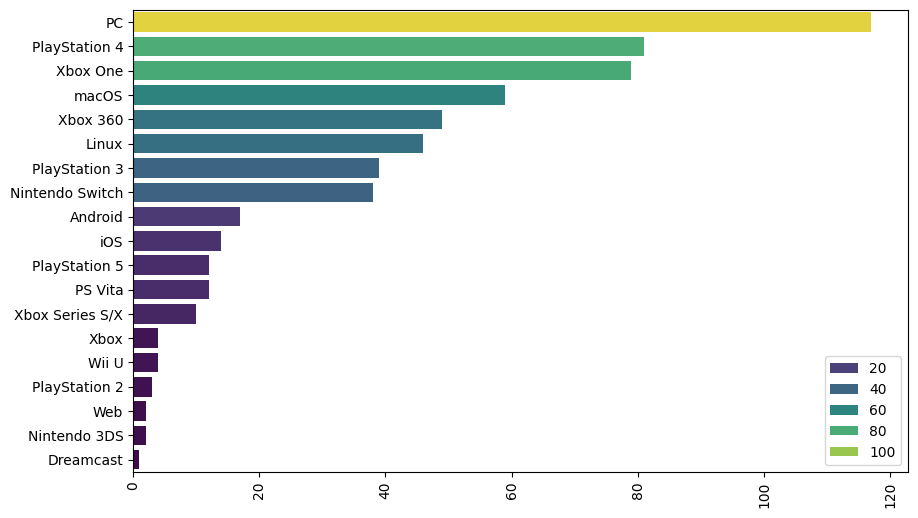

In [139]:
# Bar chart to sort which platform appears in more games
plt.figure(figsize=(10, 6))
sns.barplot(x=all_platforms.values(), y=all_platforms.keys(), hue=all_platforms.values(), palette="viridis")
plt.xticks(rotation=90)
plt.show()

In this chart we can see that PC appears in most of the games, appearing in a ratio of 78%, followed by Xbox One and Playstation 4

### Investigating `esrb_rating` column

In this case, I'm not dealing with NaN values yet, but the column `esrb_rating` have NaN values, because I don't want them to appear in my analysis I will simply not include them on my dictionary, and on my chart. The NaN values will be deal with on the next steps.

In [140]:
df_copy['esrb_rating'] = df_copy['esrb_rating'].fillna("Not Rated")

In [141]:
esrb_rating = {}
for rate in df_copy['esrb_rating']:
    if pd.notna(rate):
        if rate not in esrb_rating:
            esrb_rating[rate] = 1
        else:
            esrb_rating[rate] += 1
print(esrb_rating)

{'Mature': 75, 'Teen': 16, 'Not Rated': 16, 'Everyone 10+': 6, 'Everyone': 3, 'Adults Only': 3, 'Rating Pending': 1}


<Axes: >

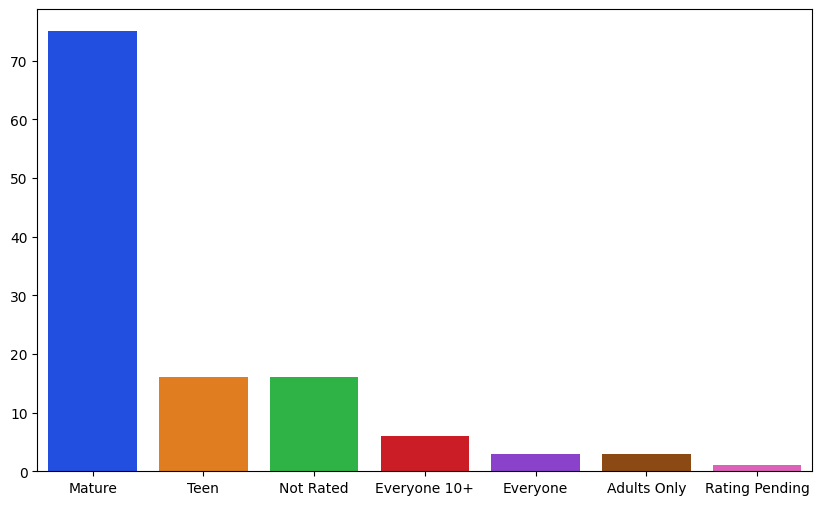

In [142]:
# Creating a barchart
plt.figure(figsize=(10, 6))
sns.barplot(x=esrb_rating.keys(), y=esrb_rating.values(), hue=esrb_rating.keys(), palette="bright")

### Investigating `tags` column

In [143]:
tags = {}
for tags_list in df['tags']:
    for tag in tags_list.split(","):
        tag = tag.strip()
        if tag not in tags:
            tags[tag] = 1
        else:
            tags[tag] += 1

print(tags)

{'Singleplayer': 106, 'Steam Achievements': 69, 'Full controller support': 64, 'Steam Cloud': 53, 'Atmospheric': 97, 'steam-trading-cards': 49, 'Great Soundtrack': 63, 'RPG': 49, 'Story Rich': 67, 'Open World': 53, 'Third Person': 50, 'Fantasy': 19, 'Gore': 22, 'Violent': 14, 'Stealth': 28, 'Action RPG': 25, 'Anime': 3, 'Hack and Slash': 12, 'War': 8, 'In-App Purchases': 9, 'Dark Fantasy': 13, 'Medieval': 6, 'Magic': 9, 'Multiplayer': 64, 'Co-op': 39, 'First-Person': 54, 'Partial Controller Support': 33, 'FPS': 49, 'Online Co-Op': 28, 'Exploration': 31, 'Sandbox': 31, 'Third-Person Shooter': 23, 'PvP': 13, 'Realistic': 5, 'Mature': 14, 'Cinematic': 20, 'Historical': 5, 'Crime': 11, 'Online PvP': 2, '3rd-Person Perspective': 14, 'Blood': 6, 'America': 5, 'Masterpiece': 5, 'Beautiful': 3, 'Hunting': 3, 'Western': 2, '3rd-person': 2, 'cooperative': 32, 'Sci-fi': 44, 'Free to Play': 12, 'Online multiplayer': 7, 'Action-Adventure': 21, 'Space': 9, 'combat': 5, 'Futuristic': 12, 'Aliens': 9,

In [144]:
top_20_tags = dict(
    sorted(
        tags.items(),
        key=lambda item: item[1],
        reverse=True
    )[:20]
)
print(top_20_tags)

{'Singleplayer': 106, 'Atmospheric': 97, 'Steam Achievements': 69, 'Story Rich': 67, 'Full controller support': 64, 'Multiplayer': 64, 'Great Soundtrack': 63, 'First-Person': 54, 'Steam Cloud': 53, 'Open World': 53, 'Third Person': 50, 'steam-trading-cards': 49, 'RPG': 49, 'FPS': 49, 'Sci-fi': 44, 'Co-op': 39, 'Partial Controller Support': 33, 'cooperative': 32, 'Horror': 32, 'Exploration': 31}


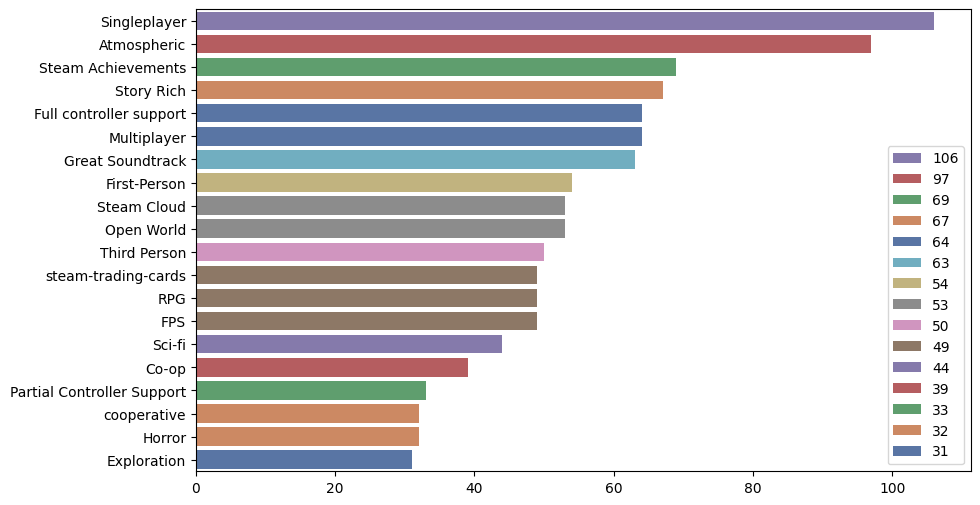

In [145]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=top_20_tags.values(), y=top_20_tags.keys(), hue=top_20_tags.values(), palette="deep")
sns.move_legend(barplot, loc='lower right', reverse=True)
plt.show()

### Investigating `released` column

What I'm thinking is to create a chart that shows how many games were released by year, and I want to create a time series chart that shows how many games were released on each month in each year

In [146]:
# First I will create a pie chart to visualize the released games per year
years = df_copy['released']
total_year_occurrencies = {}
for year in years:
    released_year = year.year
    if released_year not in total_year_occurrencies:
        total_year_occurrencies[released_year] = 1
    else:
        total_year_occurrencies[released_year] += 1
print(total_year_occurrencies)

{2017: 11, 2018: 5, 2015: 14, 2004: 5, 2011: 6, 2002: 1, 2016: 14, 2013: 11, 2012: 11, 2010: 10, 2014: 7, 2007: 5, 2008: 5, 2009: 3, 2006: 2, 1998: 1, 2005: 1, 2000: 1, 2020: 3, 2019: 4}


In [147]:
total_year_occurrencies = dict(
    sorted(total_year_occurrencies.items())
)
print(total_year_occurrencies)

{1998: 1, 2000: 1, 2002: 1, 2004: 5, 2005: 1, 2006: 2, 2007: 5, 2008: 5, 2009: 3, 2010: 10, 2011: 6, 2012: 11, 2013: 11, 2014: 7, 2015: 14, 2016: 14, 2017: 11, 2018: 5, 2019: 4, 2020: 3}


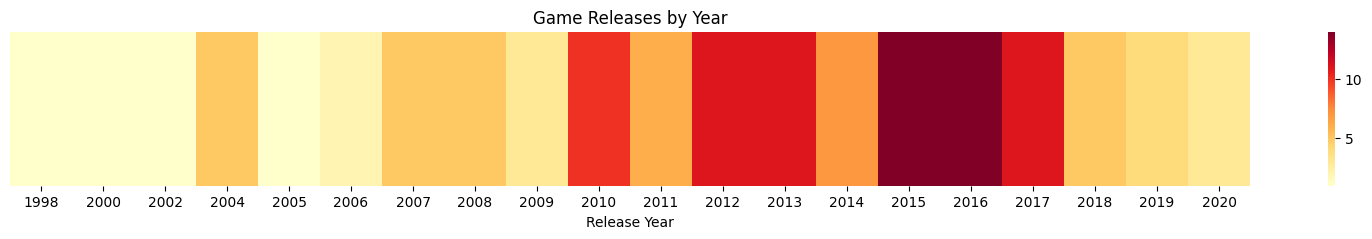

In [148]:
year_heatmap = pd.DataFrame(
    [list(total_year_occurrencies.values())],
    columns=total_year_occurrencies.keys()
)

plt.figure(figsize=(20, 2))

sns.heatmap(
    year_heatmap,
    annot=False,
    fmt='d',
    cmap='YlOrRd',
    cbar=True
)

plt.title('Game Releases by Year')
plt.xlabel('Release Year')
plt.yticks([])

plt.show()

In [149]:
# After checking my heatmap, I tought of creating time series charts for the top 3 most released years
top_3_years = dict(
    sorted(
        total_year_occurrencies.items(),
        key=lambda item: item[1],
        reverse=True
    )[:3]
)
print(top_3_years.keys())

dict_keys([2015, 2016, 2012])


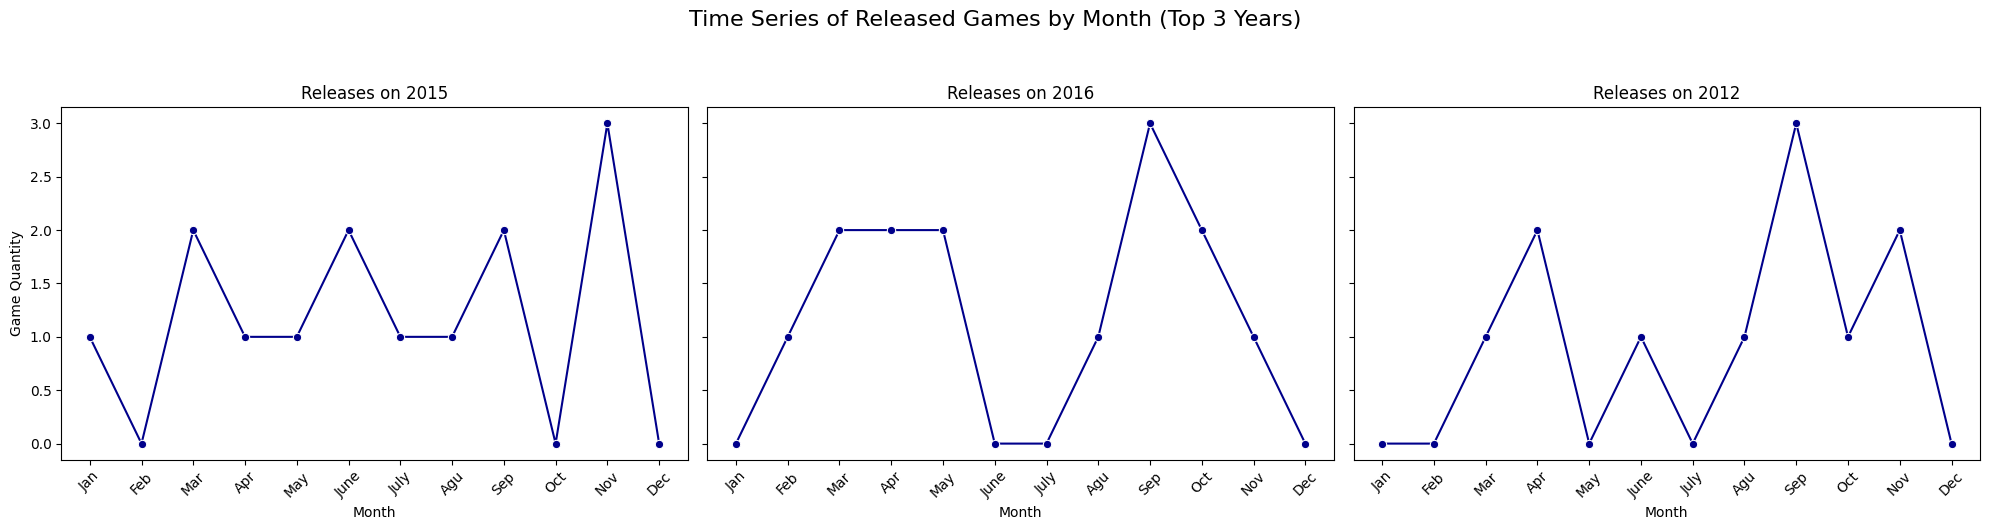

In [150]:
# 1. Get the list with the top 3 years
target_years = list(top_3_years.keys())

# creating new columns: released formatted for datetime, year and month
df_copy['released'] = pd.to_datetime(df_copy["released"], errors="coerce")
df_copy['year'] = df_copy['released'].dt.year
df_copy['month'] = df_copy['released'].dt.month

# 2. Creating the figure for the three plots (1 line, 3 columns) using subplot
# that way we can show all three plots on a same line side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for i, year in enumerate(target_years):
    # Filtering the data only for the actual iteration year
    df_year = df_copy[df_copy['year'] == year]
    
    # Groupby month and counting the release volume
    monthly_data = df_year.groupby('month')['id'].count().reset_index()
    
    # Making sure all month (1 to 12) appear on the plot, even if it has any month with zero value
    monthly_data = monthly_data.set_index('month').reindex(range(1, 13), fill_value=0).reset_index()
    
    # Plotting the line chart on the specific subplot
    sns.lineplot(
        data=monthly_data, 
        x='month', 
        y='id', 
        marker='o', 
        color='darkblue', 
        ax=axes[i]
    )
    
    # Chart customization
    axes[i].set_title(f'Releases on {int(year)}')
    axes[i].set_xlabel('Month')
    axes[i].set_xticks(range(1, 13)) # Show all months on x axis
    
    # Changing the month numbers for the month's names
    axes[i].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Agu', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

# Título geral da figura
axes[0].set_ylabel('Game Quantity')
plt.suptitle('Time Series of Released Games by Month (Top 3 Years)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Investigating `genres` column

In [151]:
all_genres = {}

for list_of_genres in df_copy['genres']:
    formatted_genres_strings = [genre.strip() for genre in list_of_genres.split(',')]
    for genre in formatted_genres_strings:
        genre = genre.strip()
        if genre not in all_genres:
            all_genres[genre] = 1
        else:
            all_genres[genre] += 1
all_genres

{'Action': 106,
 'RPG': 33,
 'Shooter': 47,
 'Adventure': 25,
 'Platformer': 5,
 'Fighting': 2,
 'Massively Multiplayer': 9,
 'Indie': 21,
 'Simulation': 6,
 'Puzzle': 4,
 'Family': 1,
 'Sports': 2,
 'Racing': 1,
 'Arcade': 3,
 'Casual': 2,
 'Strategy': 4}

In [152]:
# Selecting the top 6 game genres

# Transforming my Dictionary to a pandas Series
series_all_genres = pd.Series(all_genres)

# Selecting the Top 6 biggest Genres
top_6_genres = series_all_genres.nlargest(6)

# Sum all value for Other genres
other_values = series_all_genres.iloc[6:].sum()

# Create a new Series and add the Other values
other_series = pd.Series({'Others': other_values})

# Concat both Series
genre_data_for_plot = pd.concat([top_6_genres, other_series])

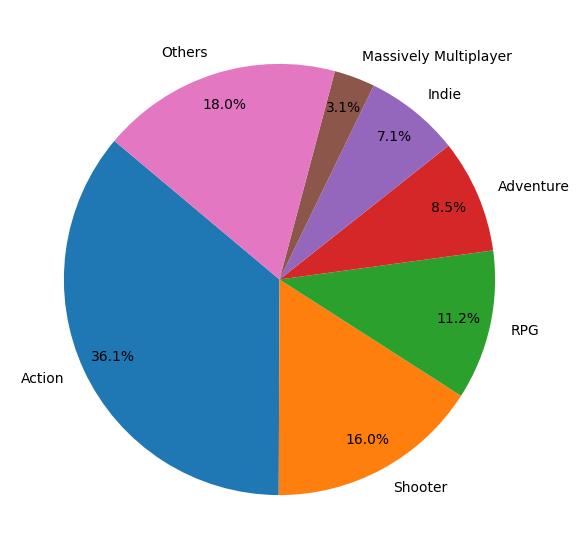

In [153]:
plt.figure(figsize=(15, 7))
plt.pie(
    x=genre_data_for_plot.values, 
    labels=genre_data_for_plot.index,
    autopct='%1.1f%%', # Show the percentage of each slice
    startangle=140,    # Rotate the chart
    pctdistance=0.85   # Distance from the text to the center
)
plt.show()

In [154]:
df_copy.groupby('metacritic')['name'].sum()

metacritic
70.0                                ARK: Survival Evolved
73.0                        WarframeMad MaxCyberpunk 2077
74.0    Just Cause 3The Elder Scrolls V: Skyrim Specia...
75.0                          Borderlands: The Pre-Sequel
76.0    Mortal Kombat XFor HonorMetro: Last Light Redu...
78.0                                             Paladins
79.0    PAYDAY 2Hitman: AbsolutionMetro 2033Detroit: B...
80.0    PreyMetal Gear Solid V: Ground ZeroesOutlastCo...
81.0    Little NightmaresTerrariaBatman: Arkham Knight...
82.0                 Middle-earth: Shadow of WarDestiny 2
83.0    Deus Ex: Mankind DividedLife is StrangeL.A. No...
84.0    Fallout 4Saints Row: The ThirdJust Cause 2Fall...
85.0    Resident Evil 7: BiohazardDOOM (2016)Hotline M...
86.0    BastionDishonored 2Rocket LeagueDead Space (20...
87.0    Titanfall 2Super Meat BoyHalf-Life 2: Episode ...
88.0    LimboMetro 2033 ReduxFar Cry 3BioShock 2Hollow...
89.0    Horizon Zero DawnStardew ValleyBorderlands 2Da...
90.

Before entering the Bivariate Analysis, it is important to describe a very important discovery, that is the motive of why explora data through visual analysis, the motive is that when dealing whith data, we in fact don't know the context of that data, we see numbers, and sometimes strings, but we don't know what they mean, that's why creating the context is very important, so what I did here was literally this step, where I found out what kind of public play games, which genres are their favorite, the many tags that describe a game, which genres they have, things like that, that way I could understand better what kind of data I was dealing with, and most important, I understood why I should go to the next step: Bivariate Analysis, some types of data, do not shows us anything when they are alone, in this case metacritic and rating, won't show us nothing, for an example. That's why we go to the next step using multiple variables to understand even more our data, and starting to create our own insights and questions that we want to answer.

Before entering the Bivariate Analysis, it is important to document a major breakthrough in my understanding of data: the true purpose of Exploratory Data Analysis (EDA). When we first look at a raw dataset, we don't know its real context; we just see numbers and strings. Visual analysis allows us to build that context. In this Univariate step, I discovered who the audience is, their favorite genres, the tags that describe the games, and which platforms dominate. I map out the environment.

More importantly, this step revealed why moving to Bivariate Analysis is essential. Some variables, such as metacritic and rating, offer very little value when analyzed in isolation. They are metrics that demand context. By advancing to the next step and crossing multiple variables, we can unlock deeper insights and begin to answer the real, impactful questions hidden within the data.

## Dealing With Missing Values 

In [155]:
df_copy.head()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating,year,month
0,25,Middle-earth: Shadow of War,2017-09-27,3.86,1385,82.0,"Action, RPG","PC, Xbox One, PlayStation 4, Android","Singleplayer, Steam Achievements, Full control...",Mature,2017,9
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature,2018,10
2,32,Destiny 2,2017-09-06,3.52,2670,82.0,"Action, Shooter","PlayStation 4, Xbox One, PC, Web, Xbox Series ...","Singleplayer, Multiplayer, Full controller sup...",Teen,2017,9
3,39,Prey,2017-05-05,4.28,2244,80.0,"Action, Shooter, RPG","Xbox One, PC, PlayStation 4","Singleplayer, Steam Achievements, Full control...",Mature,2017,5
4,41,Little Nightmares,2017-04-27,4.04,1639,81.0,"Action, Adventure, Platformer","iOS, PlayStation 4, PC, Xbox One, Nintendo Switch","Singleplayer, Steam Achievements, Full control...",Not Rated,2017,4


In [156]:
df_copy.isna().sum()

id               0
name             0
released         0
rating           0
ratings_count    0
metacritic       7
genres           0
platforms        0
tags             0
esrb_rating      0
year             0
month            0
dtype: int64

In [157]:
df_copy[df_copy['metacritic'].isna()]

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating,year,month
67,9721,Garry's Mod,2004-12-24,3.81,1610,NaN,"Action, Adventure, Simulation, Casual, Indie","Linux, macOS, PC","Singleplayer, Steam Achievements, Multiplayer,...",Rating Pending,2004,12
78,10754,BioShock Remastered,2016-09-15,4.24,1422,NaN,Shooter,"PlayStation 4, Nintendo Switch, macOS, PC, Xbo...","Singleplayer, Steam Achievements, Full control...",Mature,2016,9
80,11142,BioShock 2 Remastered,2016-09-15,4.00,1013,NaN,"Action, RPG","PlayStation 4, macOS, PC, Xbox One, Nintendo S...","Singleplayer, Steam Achievements, Multiplayer,...",Mature,2016,9
81,11147,ARK: Survival Of The Fittest,2016-03-15,2.60,523,NaN,"Action, RPG, Strategy, Massively Multiplayer, ...","Android, Linux, macOS, PC, iOS","Singleplayer, Multiplayer, RPG, Co-op, Open Wo...",Teen,2016,3
84,11935,Half-Life Deathmatch: Source,2006-05-01,3.21,729,NaN,Action,"macOS, Linux, PC","Multiplayer, First-Person, Sci-fi, Horror, FPS...",Mature,2006,5
85,11936,Half-Life 2: Deathmatch,2004-11-01,3.29,909,NaN,Action,"Linux, macOS, PC","Multiplayer, Atmospheric, Co-op, cooperative, ...",Mature,2004,11
101,19103,Half-Life 2: Lost Coast,2005-10-27,3.45,1175,NaN,Action,"macOS, Linux, PC","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature,2005,10


In [158]:
df_copy[df_copy['esrb_rating'].isna()]

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating,year,month


## Bivariate Analysis (Insights Phase)

#### Does the General Public Rate and Metacritic have a similar rate ?

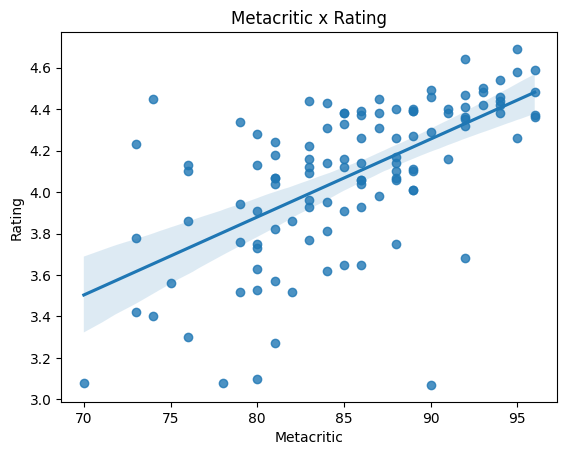

In [159]:
# Rating vs Metacritic

# 1. Creating a Scatterplot (without normalize the data)
sns.regplot(data=df_copy, x="metacritic", y="rating")
plt.xlabel("Metacritic")
plt.ylabel("Rating")
plt.title("Metacritic x Rating")
plt.show()

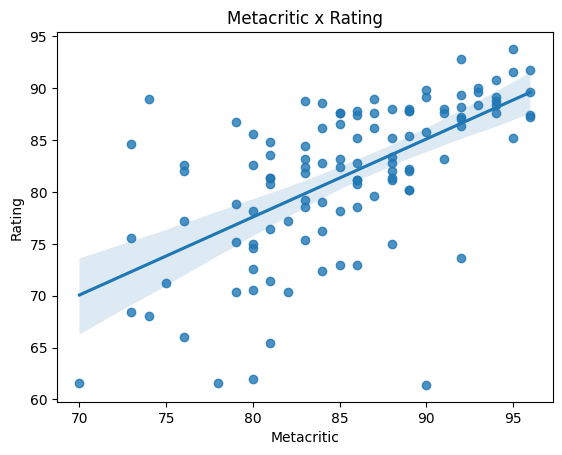

In [160]:
# 2. By normalizing the data
# Criando a coluna do público na escala de 0 a 100
df_copy['rating_100'] = df_copy['rating'] * 20

sns.regplot(data=df_copy, x="metacritic", y="rating_100")
plt.xlabel("Metacritic")
plt.ylabel("Rating")
plt.title("Metacritic x Rating")
plt.show()

#### What genre has the highest rate for the General Public ?

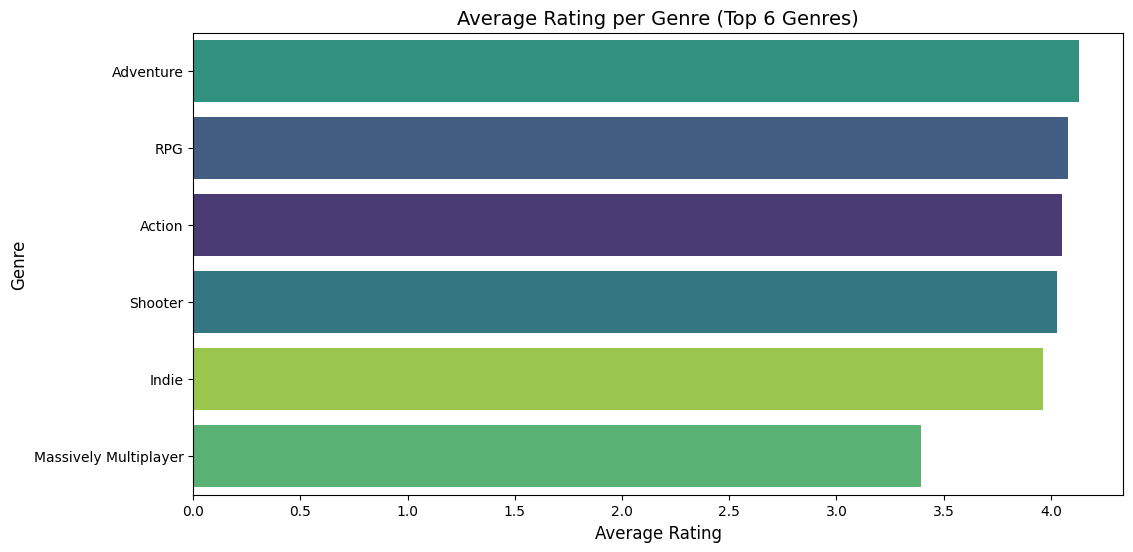

In [161]:
# 1. Create a helper DataFrame to avoid messing up the original df_copy
df_genres = df_copy[["genres", "rating"]].dropna()

# 2. Transform the genres string into an actual Python list
df_genres["genres"] = df_genres["genres"].apply(
    lambda x: [g.strip() for g in x.split(",")]
)

# 3. The explode magic: it duplicates the rows for each genre in the list
df_genres = df_genres.explode("genres")

# [Optional] Filter only by the top 6 genres discovered earlier
# This prevents the bar plot from getting cluttered with 50 rare genres
top_6_names = top_6_genres.index.tolist()
df_genres_filtered = df_genres[df_genres["genres"].isin(top_6_names)]

# --- NEW STEP: Calculate the sorted order based on average rating ---
# This groups by genre, finds the mean rating, and sorts them in descending order
sorted_order = (
    df_genres_filtered.groupby("genres")["rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Set up and plot the bar chart
plt.figure(figsize=(12, 6))

# Seaborn automatically calculates the AVERAGE 'rating' for each genre
sns.barplot(
    data=df_genres_filtered,
    x="rating",
    y="genres",
    estimator="mean",  # Ensures we are looking at the average rating
    errorbar=None,  # Removes the error bars for a cleaner look
    hue="genres",
    order=sorted_order,
    palette="viridis",
)

plt.title("Average Rating per Genre (Top 6 Genres)", fontsize=14)
plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.show()

#### Do games with higher engagement tend to receive better ratings?

Before creating the plot, I must understand what does it mean for a game to be popular, based on the data, beign popular could meant having a high rate, and having a high rate count. So in this case I will get the 5 most popular and 5 less popular games based on this hypothesis.

After an analysis, rating does not show that a games is popular, the value rating_count indeed show us that, that's why this analysis will be based on the `rating_count`

In [173]:
# Rating count vs rating
df_order_by_rating_count = df_copy.sort_values(by='ratings_count', ascending=True)
df_order_by_rating_count = df_order_by_rating_count.drop(columns=['year', 'month', 'rating_100'])
df_order_by_rating_count.head()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating
81,11147,ARK: Survival Of The Fittest,2016-03-15,2.60,523,NaN,"Action, RPG, Strategy, Massively Multiplayer, ...","Android, Linux, macOS, PC, iOS","Singleplayer, Multiplayer, RPG, Co-op, Open Wo...",Teen
69,9810,ARK: Survival Evolved,2015-06-02,3.08,670,70.0,"Action, Adventure, RPG, Massively Multiplayer,...","Nintendo Switch, Xbox One, PlayStation 4, Linu...","Singleplayer, Steam Achievements, Multiplayer,...",Not Rated
84,11935,Half-Life Deathmatch: Source,2006-05-01,3.21,729,NaN,Action,"macOS, Linux, PC","Multiplayer, First-Person, Sci-fi, Horror, FPS...",Mature
76,10243,Company of Heroes 2,2013-06-25,3.10,872,80.0,Strategy,"Linux, macOS, PC","Singleplayer, Steam Achievements, Multiplayer,...",Mature
85,11936,Half-Life 2: Deathmatch,2004-11-01,3.29,909,NaN,Action,"Linux, macOS, PC","Multiplayer, Atmospheric, Co-op, cooperative, ...",Mature


In [175]:
df_order_by_rating_count['quartile'] = pd.qcut(
    df_order_by_rating_count['ratings_count'], 
    4,
    labels=[
        'Low Popularity',
        'Medium Popularity',
        'High Popularity',
        'Very High Popularity'
    ]
)
df_order_by_rating_count.tail()

,id,name,released,rating,ratings_count,metacritic,genres,platforms,tags,esrb_rating,quartile
114,58175,God of War (2018),2018-04-20,4.54,5153,94.0,Action,"PC, PlayStation 4","Singleplayer, Steam Achievements, Full control...",Mature,Very High Popularity
1,28,Red Dead Redemption 2,2018-10-26,4.59,5498,96.0,Action,"PC, PlayStation 4, Xbox One","Singleplayer, Multiplayer, Atmospheric, Great ...",Mature,Very High Popularity
48,4200,Portal 2,2011-04-18,4.58,6102,95.0,"Shooter, Puzzle","PlayStation 3, PC, Xbox 360, Linux, macOS, Xbo...","Singleplayer, Steam Achievements, Multiplayer,...",Everyone 10+,Very High Popularity
31,3328,The Witcher 3: Wild Hunt,2015-05-18,4.64,7196,92.0,"Action, RPG","PlayStation 5, Xbox Series S/X, macOS, PlaySta...","Singleplayer, Full controller support, Atmosph...",Mature,Very High Popularity
34,3498,Grand Theft Auto V,2013-09-17,4.47,7384,92.0,Action,"PlayStation 5, Xbox Series S/X, PlayStation 3,...","Singleplayer, Steam Achievements, Multiplayer,...",Mature,Very High Popularity


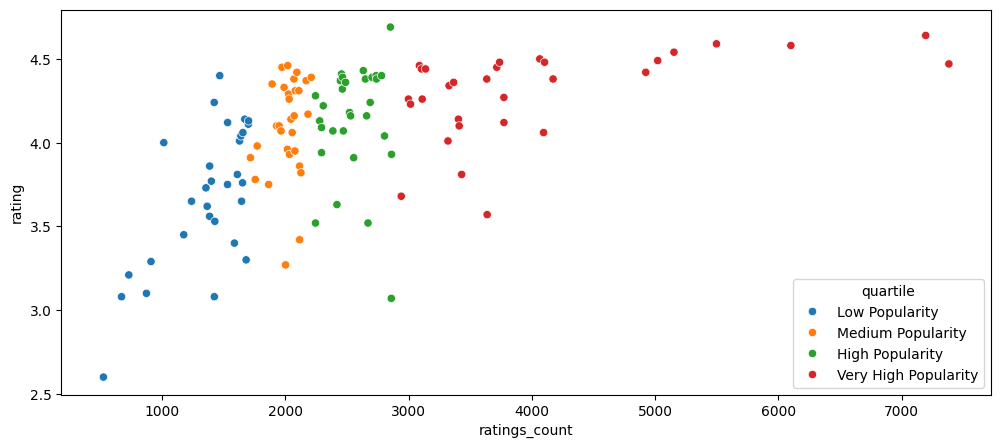

In [189]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_order_by_rating_count, x='ratings_count', y='rating', hue='quartile')
plt.show()

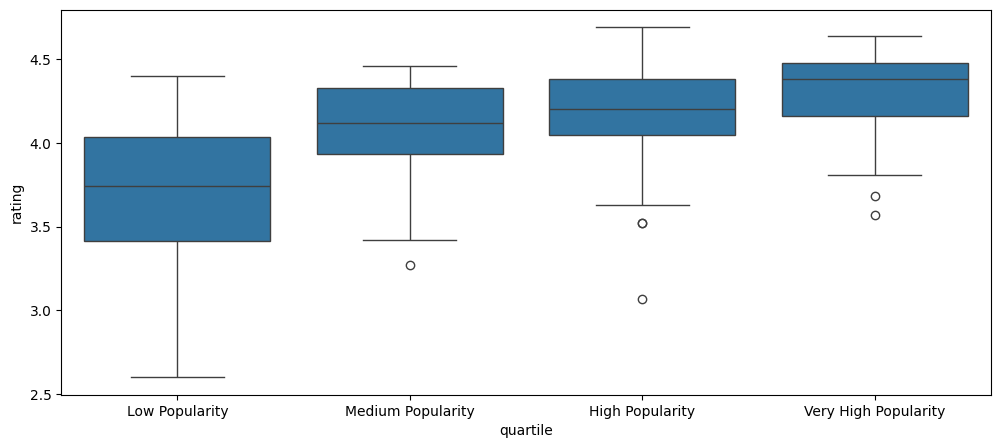

In [190]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_order_by_rating_count, x='quartile', y='rating')
plt.show()

The scatterplot suggests a positive relationship between player engagement and user ratings.
Games with higher engagement levels appear concentrated in higher rating ranges, while low-engagement games show greater variability and lower extreme values.

#### Does mature games perform better ?

In [116]:
# ESRB vs Average Rating

#### Does plataforms impact on a better avaliation ?

In [117]:
# Plataform vs average rating

#### Does the Average public likes the same genre as metacritics ?

In [118]:
# Genre vs metacritic